In [11]:
import pandas as pd
import sys
import importlib

In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
sys.path.append("../src")
import eda_utils as eda
import modeling as mod
import visualization as visual
import data_splitting as split
import preprocessing as prep

importlib.reload(eda)
importlib.reload(visual)
importlib.reload(prep)

<module 'preprocessing' from '/home/abril/UdeSA/ML/TP_Final_ML/notebooks/../src/preprocessing.py'>

In [14]:
X_train_pp = pd.read_csv("../data/X_train_pp.csv")
X_val_pp = pd.read_csv("../data/X_val_pp.csv")

# Datasests pre one-hot for cross validation
X_train = pd.read_csv("../data/X_train.csv")
X_val = pd.read_csv("../data/X_val.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_val = pd.read_csv("../data/y_val.csv").squeeze()

# Feature Engeneering

Para lograr capturar nuevas relacione sentre features, se realizan combinaciones li entre ellos. Vamos a combiar aquellos fearures con mayor correlacion con el target, juanto con featutres con correlscion entre sí y con el target. Además, se agregarán columnas ordinales para mejorar las carácteristicas del dataset

## Combining features

In [15]:
X_train_pp["antiguedad"] = 2025 - X_train_pp["Año"]
X_train_pp["km_por_año"] = X_train_pp["Kilómetros"] / X_train_pp["antiguedad"].clip(lower=1)
X_train_pp["0km"] = (X_train_pp["Kilómetros"] == 0).astype(int)
X_train_pp["cilindrada_turbo"] = X_train_pp["Cilindrada"] * X_train_pp["Tiene turbo"]

X_val_pp["antiguedad"] = 2025 - X_val_pp["Año"]
X_val_pp["km_por_año"] = X_val_pp["Kilómetros"] / X_val_pp["antiguedad"].clip(lower=1)
X_val_pp["0km"] = (X_val_pp["Kilómetros"] == 0).astype(int)
X_val_pp["cilindrada_turbo"] = X_val_pp["Cilindrada"] * X_val_pp["Tiene turbo"]

/tmp/ipykernel_56304/1783677381.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train_pp["antiguedad"] = 2025 - X_train_pp["Año"]
/tmp/ipykernel_56304/1783677381.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train_pp["km_por_año"] = X_train_pp["Kilómetros"] / X_train_pp["antiguedad"].clip(lower=1)
/tmp/ipykernel_56304/1783677381.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once

In [16]:
xgboost_log_model, xgboost_log_metrics = mod.train_xgboost(
    X_train_pp,
    y_train,
    X_val_pp,
    y_val,
    use_log_target=True,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
)

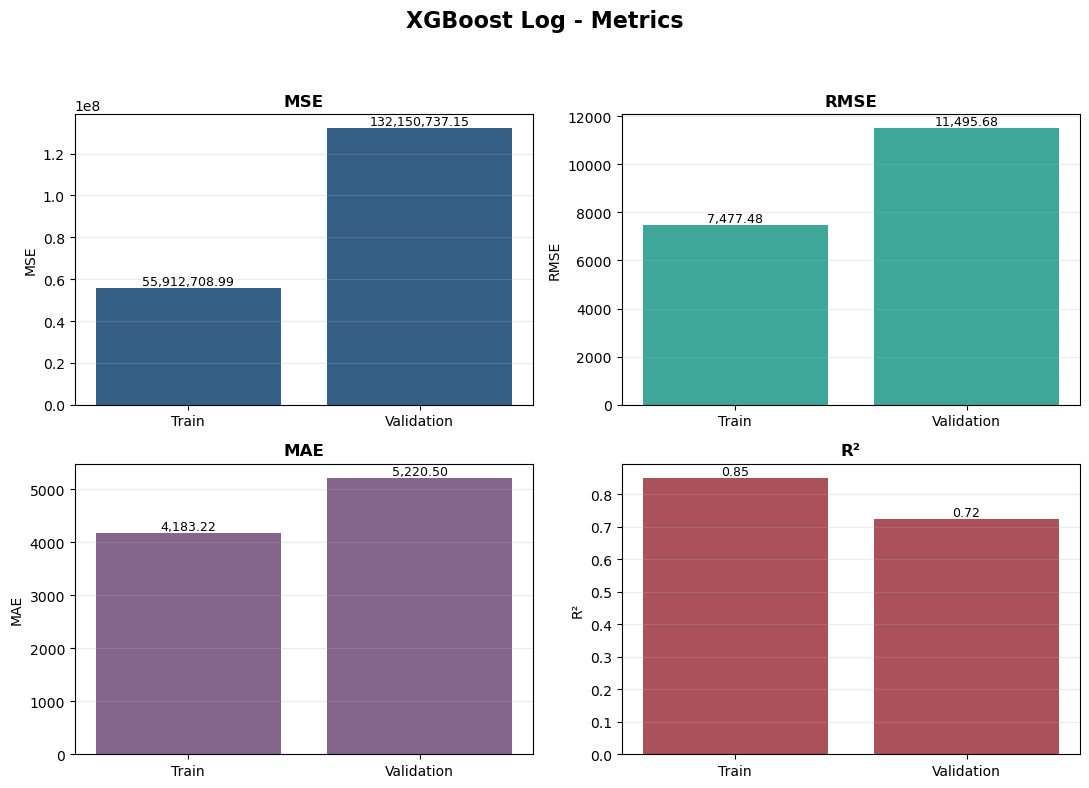

In [17]:
visual.plot_regression_metrics(
    xgboost_log_metrics,
    model_name="XGBoost Log",
)